In [19]:
import torch
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor

import numpy as np
import math
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(100)

In [20]:
# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [21]:
# MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='/data',
                                           train=True,
                                           transform=transforms.ToTensor(),
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='/data',
                                          train=False,
                                          transform=transforms.ToTensor())

train_dataset = [image for image in train_dataset if (image[1]==1 or image[1]==0 )]
print(len(train_dataset))

test_dataset = [image for image in test_dataset if (image[1]==1 or image[1]==0 )]
print(len(test_dataset))

12665
2115


In [22]:
# images in the dataset are stored as a tensor data
# for example you can print the label and tensor data of the 10th image in the dataset as follow :
print ()
print("label : " + str(train_dataset[9][1]))
print("image tensor : " + str(train_dataset[9][0]))


label : 0
image tensor : tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.000

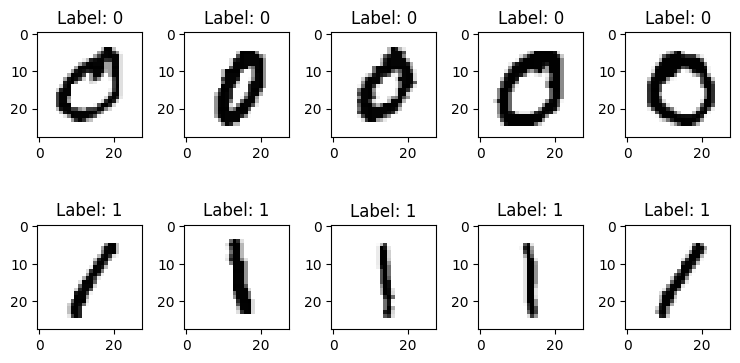

In [23]:
def plot_set_images(n_row, n_col, images, labels, label_text="Label: "):
  num=len(images)
  num_row=n_row
  num_col=n_col
  fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
  for i in range(num):
      ax = axes[i//num_col, i%num_col]
      ax.imshow(images[i].reshape(28, 28), cmap='gray_r')
      ax.set_title('{}{}'.format(label_text, labels[i]))
  plt.tight_layout()
  plt.show()

images_set = []
labels_set = []
j=0
for i in range(2):
  j = 0
  for _ in range(5):
    j += 1
    while i != train_dataset[j][1]:
      j += 1
    images_set.append(train_dataset[j][0])
    labels_set.append(train_dataset[j][1])
plot_set_images(2, 5, images_set, labels_set, "Label: ")

In [24]:
#Part1
# Preprocessing the Data

# Flatten images and normalize pixel values to range [0, 1]
def preprocess_data(dataset):
    images = torch.stack([sample[0] for sample in dataset])  # Extract all images as tensors
    labels = torch.tensor([sample[1] for sample in dataset])  # Extract all labels

    # Flatten images to 1D arrays
    images = images.view(images.size(0), -1)  # Flatten each 28x28 image into a 1D vector of size 784

    # Normalize images to [0, 1] (already normalized by ToTensor, but ensure correctness)
    images = images / 1.0

    return images, labels

train_images, train_labels = preprocess_data(train_dataset)
test_images, test_labels = preprocess_data(test_dataset)

print(f"Training data shape: {train_images.shape}, Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_images.shape}, Test labels shape: {test_labels.shape}")


Training data shape: torch.Size([12665, 784]), Training labels shape: torch.Size([12665])
Test data shape: torch.Size([2115, 784]), Test labels shape: torch.Size([2115])


In [25]:
# Splitting the Data

# Split training data into two equal halves
split_idx = len(train_images) // 2

train_images_half1 = train_images[:split_idx]
train_labels_half1 = train_labels[:split_idx]

train_images_half2 = train_images[split_idx:]
train_labels_half2 = train_labels[split_idx:]

print(f"First half shape: {train_images_half1.shape}, Second half shape: {train_images_half2.shape}")


First half shape: torch.Size([6332, 784]), Second half shape: torch.Size([6333, 784])


In [26]:
# Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, r2_score

# Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=100)

# Train the model on the first half of the training data
model.fit(train_images_half1, train_labels_half1)

# Evaluate on the test dataset
test_preds = model.predict(test_images)

# Metrics
accuracy = accuracy_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds, average='weighted')
r2 = r2_score(test_labels, test_preds)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"R-squared Score: {r2}")


Accuracy: 0.9995271867612293
F1 Score: 0.9995271701820642
R-squared Score: 0.9980985345680122


In [27]:
# Metrics during cross-validation and on test set

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, r2_score

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

# To store metrics for cross-validation
cv_accuracies, cv_f1_scores, cv_r2_scores = [], [], []

# Perform cross-validation
fold = 1
for train_idx, val_idx in skf.split(train_images_half1, train_labels_half1):
    # Split into training and validation sets
    X_train, X_val = train_images_half1[train_idx], train_images_half1[val_idx]
    y_train, y_val = train_labels_half1[train_idx], train_labels_half1[val_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predict on validation set
    val_preds = model.predict(X_val)

    # Compute metrics
    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds, average='weighted')
    r2 = r2_score(y_val, val_preds)

    # Store metrics for this fold
    cv_accuracies.append(acc)
    cv_f1_scores.append(f1)
    cv_r2_scores.append(r2)

    # Print metrics for this fold
    print(f"Fold {fold} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, R-squared: {r2:.4f}")
    fold += 1

# Compute average metrics across all folds
avg_cv_accuracy = np.mean(cv_accuracies)
avg_cv_f1_score = np.mean(cv_f1_scores)
avg_cv_r2_score = np.mean(cv_r2_scores)

print(f"\nAverage Cross-Validation Metrics:")
print(f"Accuracy: {avg_cv_accuracy:.4f}")
print(f"F1 Score: {avg_cv_f1_score:.4f}")
print(f"R-squared: {avg_cv_r2_score:.4f}")

# Train on the entire first half of the data
model.fit(train_images_half1, train_labels_half1)

# Predict on the test set
test_preds = model.predict(test_images)

# Compute metrics on the test set
test_accuracy = accuracy_score(test_labels, test_preds)
test_f1_score = f1_score(test_labels, test_preds, average='weighted')
test_r2_score = r2_score(test_labels, test_preds)

# Print test set metrics
print(f"\nTest Set Metrics (After Training with Half the Data):")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {test_f1_score:.4f}")
print(f"R-squared: {test_r2_score:.4f}")



Fold 1 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968
Fold 2 - Accuracy: 0.9968, F1 Score: 0.9968, R-squared: 0.9873
Fold 3 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9936
Fold 4 - Accuracy: 0.9976, F1 Score: 0.9976, R-squared: 0.9905
Fold 5 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9936

Average Cross-Validation Metrics:
Accuracy: 0.9981
F1 Score: 0.9981
R-squared: 0.9924

Test Set Metrics (After Training with Half the Data):
Accuracy: 0.9995
F1 Score: 0.9995
R-squared: 0.9981


In [28]:
# Question 6, Condition 1: Train the model on the entire training data and evaluate on the test set
# Train the model on the full training data
model.fit(train_images, train_labels)

# Predict on the test set
test_preds_full_train = model.predict(test_images)

# Compute metrics
accuracy_full_train = accuracy_score(test_labels, test_preds_full_train)
f1_full_train = f1_score(test_labels, test_preds_full_train, average='weighted')
r2_full_train = r2_score(test_labels, test_preds_full_train)

# Print metrics
print(f"Metrics when trained on the entire training data:")
print(f"Accuracy: {accuracy_full_train:.4f}")
print(f"F1 Score: {f1_full_train:.4f}")
print(f"R-squared: {r2_full_train:.4f}")


Metrics when trained on the entire training data:
Accuracy: 0.9995
F1 Score: 0.9995
R-squared: 0.9981


In [29]:
# Question 6,  Condition 2: Cross-validate on one half, then train on combined data and evaluate on the test set
from sklearn.model_selection import StratifiedKFold

# Initialize 5-fold cross-validation
skf_half = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

cv_accuracies_half, cv_f1_scores_half, cv_r2_scores_half = [], [], []

# Cross-validation on the first half of the training data
fold = 1
for train_idx, val_idx in skf_half.split(train_images_half1, train_labels_half1):
    X_train, X_val = train_images_half1[train_idx], train_images_half1[val_idx]
    y_train, y_val = train_labels_half1[train_idx], train_labels_half1[val_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predict on validation set
    val_preds = model.predict(X_val)

    # Compute metrics
    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds, average='weighted')
    r2 = r2_score(y_val, val_preds)

    cv_accuracies_half.append(acc)
    cv_f1_scores_half.append(f1)
    cv_r2_scores_half.append(r2)

    print(f"Fold {fold} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, R-squared: {r2:.4f}")
    fold += 1

# Compute average metrics across all folds
avg_cv_accuracy_half = np.mean(cv_accuracies_half)
avg_cv_f1_score_half = np.mean(cv_f1_scores_half)
avg_cv_r2_score_half = np.mean(cv_r2_scores_half)

print(f"\nAverage Cross-Validation Metrics on First Half of the Data:")
print(f"Accuracy: {avg_cv_accuracy_half:.4f}")
print(f"F1 Score: {avg_cv_f1_score_half:.4f}")
print(f"R-squared: {avg_cv_r2_score_half:.4f}")

# Combine the cross-validated half with the untouched half
combined_train_images = np.vstack((train_images_half1, train_images_half2))
combined_train_labels = np.hstack((train_labels_half1, train_labels_half2))

# Train the model on the combined data
model.fit(combined_train_images, combined_train_labels)

# Predict on the test set
test_preds_combined_train = model.predict(test_images)

# Compute metrics on the test set
accuracy_combined_train = accuracy_score(test_labels, test_preds_combined_train)
f1_combined_train = f1_score(test_labels, test_preds_combined_train, average='weighted')
r2_combined_train = r2_score(test_labels, test_preds_combined_train)

# Print metrics on the test set
print(f"\nMetrics after training on half (validated) + untouched half of the training data:")
print(f"Accuracy: {accuracy_combined_train:.4f}")
print(f"F1 Score: {f1_combined_train:.4f}")
print(f"R-squared: {r2_combined_train:.4f}")



Fold 1 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968
Fold 2 - Accuracy: 0.9968, F1 Score: 0.9968, R-squared: 0.9873
Fold 3 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9936
Fold 4 - Accuracy: 0.9976, F1 Score: 0.9976, R-squared: 0.9905
Fold 5 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9936

Average Cross-Validation Metrics on First Half of the Data:
Accuracy: 0.9981
F1 Score: 0.9981
R-squared: 0.9924

Metrics after training on half (validated) + untouched half of the training data:
Accuracy: 0.9995
F1 Score: 0.9995
R-squared: 0.9981


In [30]:
# Question 6, Condition 3: Cross-validate on the entire training data, then train and evaluate on the test set
from sklearn.model_selection import StratifiedKFold

# Initialize 5-fold cross-validation
skf_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

cv_accuracies_full, cv_f1_scores_full, cv_r2_scores_full = [], [], []

# Perform cross-validation
fold = 1
for train_idx, val_idx in skf_full.split(train_images, train_labels):
    # Split into training and validation sets
    X_train_full, X_val_full = train_images[train_idx], train_images[val_idx]
    y_train_full, y_val_full = train_labels[train_idx], train_labels[val_idx]

    # Train model on the current fold
    model.fit(X_train_full, y_train_full)

    # Predict on the validation set
    val_preds_full = model.predict(X_val_full)

    # Compute metrics
    acc = accuracy_score(y_val_full, val_preds_full)
    f1 = f1_score(y_val_full, val_preds_full, average='weighted')
    r2 = r2_score(y_val_full, val_preds_full)

    # Store metrics for this fold
    cv_accuracies_full.append(acc)
    cv_f1_scores_full.append(f1)
    cv_r2_scores_full.append(r2)

    # Print metrics for the current fold
    print(f"Fold {fold} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, R-squared: {r2:.4f}")
    fold += 1

# Compute average metrics over all folds
avg_cv_accuracy_full = np.mean(cv_accuracies_full)
avg_cv_f1_score_full = np.mean(cv_f1_scores_full)
avg_cv_r2_score_full = np.mean(cv_r2_scores_full)

print(f"\nAverage Cross-Validation Metrics on Full Training Data:")
print(f"Accuracy: {avg_cv_accuracy_full:.4f}")
print(f"F1 Score: {avg_cv_f1_score_full:.4f}")
print(f"R-squared: {avg_cv_r2_score_full:.4f}")

# Train on the entire training data after cross-validation
model.fit(train_images, train_labels)

# Predict on the test set
test_preds_cv_full = model.predict(test_images)

# Compute metrics on the test set
accuracy_cv_full_train = accuracy_score(test_labels, test_preds_cv_full)
f1_cv_full_train = f1_score(test_labels, test_preds_cv_full, average='weighted')
r2_cv_full_train = r2_score(test_labels, test_preds_cv_full)

# Print metrics on the test set
print(f"\nTest Set Metrics (After Cross-Validation on Full Training Data):")
print(f"Accuracy: {accuracy_cv_full_train:.4f}")
print(f"F1 Score: {f1_cv_full_train:.4f}")
print(f"R-squared: {r2_cv_full_train:.4f}")


Fold 1 - Accuracy: 0.9996, F1 Score: 0.9996, R-squared: 0.9984
Fold 2 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968
Fold 3 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9937
Fold 4 - Accuracy: 0.9972, F1 Score: 0.9972, R-squared: 0.9889
Fold 5 - Accuracy: 0.9988, F1 Score: 0.9988, R-squared: 0.9952

Average Cross-Validation Metrics on Full Training Data:
Accuracy: 0.9987
F1 Score: 0.9987
R-squared: 0.9946

Test Set Metrics (After Cross-Validation on Full Training Data):
Accuracy: 0.9995
F1 Score: 0.9995
R-squared: 0.9981


In [33]:
#Part 2, Step 1: Apply t-SNE for dimensionality reduction
from sklearn.manifold import TSNE

# Flatten the images
train_images_flattened = train_images.reshape(len(train_images), -1)
test_images_flattened = test_images.reshape(len(test_images), -1)

# Apply t-SNE to reduce dimensionality to 2
tsne = TSNE(n_components=2, random_state=100, n_iter=3000, perplexity=30)

train_images_tsne = tsne.fit_transform(train_images_flattened)
test_images_tsne = tsne.fit_transform(test_images_flattened)

print(f"Reduced dimensionality: Train set shape: {train_images_tsne.shape}, Test set shape: {test_images_tsne.shape}")


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Reduced dimensionality: Train set shape: (12665, 2), Test set shape: (2115, 2)


In [34]:
# Split the t-SNE reduced data into two halves
split_idx_tsne = len(train_images_tsne) // 2

train_images_half1_tsne = train_images_tsne[:split_idx_tsne]
train_labels_half1_tsne = train_labels[:split_idx_tsne]

train_images_half2_tsne = train_images_tsne[split_idx_tsne:]
train_labels_half2_tsne = train_labels[split_idx_tsne:]

print(f"First half shape: {train_images_half1_tsne.shape}, Second half shape: {train_images_half2_tsne.shape}")


First half shape: (6332, 2), Second half shape: (6333, 2)


In [35]:
# Part 2, Condition 1: Train on the entire t-SNE reduced training data and evaluate on the test set
# Train the model on the full t-SNE reduced training data
model.fit(train_images_tsne, train_labels)

# Predict on the test set
test_preds_full_tsne = model.predict(test_images_tsne)

# Compute metrics
accuracy_full_tsne = accuracy_score(test_labels, test_preds_full_tsne)
f1_full_tsne = f1_score(test_labels, test_preds_full_tsne, average='weighted')
r2_full_tsne = r2_score(test_labels, test_preds_full_tsne)

# Print metrics
print(f"Metrics when trained on the entire t-SNE reduced training data:")
print(f"Accuracy: {accuracy_full_tsne:.4f}")
print(f"F1 Score: {f1_full_tsne:.4f}")
print(f"R-squared: {r2_full_tsne:.4f}")


Metrics when trained on the entire t-SNE reduced training data:
Accuracy: 0.9991
F1 Score: 0.9991
R-squared: 0.9962


In [36]:
# Part 2, Condition 2: Cross-validate on one half, then train on combined data and evaluate on the test set
from sklearn.model_selection import StratifiedKFold

# Initialize 5-fold cross-validation
skf_half = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

cv_accuracies_half, cv_f1_scores_half, cv_r2_scores_half = [], [], []

# Cross-validation on the first half of the t-SNE reduced data
fold = 1
for train_idx, val_idx in skf_half.split(train_images_half1_tsne, train_labels_half1_tsne):
    X_train, X_val = train_images_half1_tsne[train_idx], train_images_half1_tsne[val_idx]
    y_train, y_val = train_labels_half1_tsne[train_idx], train_labels_half1_tsne[val_idx]

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)

    acc = accuracy_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds, average='weighted')
    r2 = r2_score(y_val, val_preds)

    cv_accuracies_half.append(acc)
    cv_f1_scores_half.append(f1)
    cv_r2_scores_half.append(r2)

    print(f"Fold {fold} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, R-squared: {r2:.4f}")
    fold += 1

# Compute average metrics over all folds
avg_cv_accuracy_half = np.mean(cv_accuracies_half)
avg_cv_f1_score_half = np.mean(cv_f1_scores_half)
avg_cv_r2_score_half = np.mean(cv_r2_scores_half)

print(f"\nAverage Cross-Validation Metrics on First Half of t-SNE Reduced Data:")
print(f"Accuracy: {avg_cv_accuracy_half:.4f}")
print(f"F1 Score: {avg_cv_f1_score_half:.4f}")
print(f"R-squared: {avg_cv_r2_score_half:.4f}")

# Combine the cross-validated half with the untouched half
combined_train_images_tsne = np.vstack((train_images_half1_tsne, train_images_half2_tsne))
combined_train_labels_tsne = np.hstack((train_labels_half1_tsne, train_labels_half2_tsne))

# Train the model on the combined data
model.fit(combined_train_images_tsne, combined_train_labels_tsne)

# Predict on the test set
test_preds_combined_tsne = model.predict(test_images_tsne)

# Compute metrics
accuracy_combined_tsne = accuracy_score(test_labels, test_preds_combined_tsne)
f1_combined_tsne = f1_score(test_labels, test_preds_combined_tsne, average='weighted')
r2_combined_tsne = r2_score(test_labels, test_preds_combined_tsne)

# Print metrics
print(f"\nMetrics after training on half (validated) + untouched half of the t-SNE reduced data:")
print(f"Accuracy: {accuracy_combined_tsne:.4f}")
print(f"F1 Score: {f1_combined_tsne:.4f}")
print(f"R-squared: {r2_combined_tsne:.4f}")


Fold 1 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968
Fold 2 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9937
Fold 3 - Accuracy: 1.0000, F1 Score: 1.0000, R-squared: 1.0000
Fold 4 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9936
Fold 5 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968

Average Cross-Validation Metrics on First Half of t-SNE Reduced Data:
Accuracy: 0.9991
F1 Score: 0.9991
R-squared: 0.9962

Metrics after training on half (validated) + untouched half of the t-SNE reduced data:
Accuracy: 0.9991
F1 Score: 0.9991
R-squared: 0.9962


In [37]:
# Part 2, Condition 3: Cross-validate on the entire t-SNE reduced training data, then train and evaluate on the test set
from sklearn.model_selection import StratifiedKFold

# Initialize 5-fold cross-validation
skf_full_tsne = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

cv_accuracies_full_tsne, cv_f1_scores_full_tsne, cv_r2_scores_full_tsne = [], [], []

# Perform cross-validation
fold = 1
for train_idx, val_idx in skf_full_tsne.split(train_images_tsne, train_labels):
    # Split into training and validation sets
    X_train_tsne, X_val_tsne = train_images_tsne[train_idx], train_images_tsne[val_idx]
    y_train_tsne, y_val_tsne = train_labels[train_idx], train_labels[val_idx]

    # Train model on the current fold
    model.fit(X_train_tsne, y_train_tsne)

    # Predict on the validation set
    val_preds_tsne = model.predict(X_val_tsne)

    # Compute metrics
    acc = accuracy_score(y_val_tsne, val_preds_tsne)
    f1 = f1_score(y_val_tsne, val_preds_tsne, average='weighted')
    r2 = r2_score(y_val_tsne, val_preds_tsne)

    cv_accuracies_full_tsne.append(acc)
    cv_f1_scores_full_tsne.append(f1)
    cv_r2_scores_full_tsne.append(r2)

    # Print metrics for the current fold
    print(f"Fold {fold} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, R-squared: {r2:.4f}")
    fold += 1

# Compute average metrics over all folds
avg_cv_accuracy_full_tsne = np.mean(cv_accuracies_full_tsne)
avg_cv_f1_score_full_tsne = np.mean(cv_f1_scores_full_tsne)
avg_cv_r2_score_full_tsne = np.mean(cv_r2_scores_full_tsne)

print(f"\nAverage Cross-Validation Metrics on Full t-SNE Reduced Training Data:")
print(f"Accuracy: {avg_cv_accuracy_full_tsne:.4f}")
print(f"F1 Score: {avg_cv_f1_score_full_tsne:.4f}")
print(f"R-squared: {avg_cv_r2_score_full_tsne:.4f}")

# Train on the entire t-SNE reduced training data after cross-validation
model.fit(train_images_tsne, train_labels)

# Predict on the test set
test_preds_cv_full_tsne = model.predict(test_images_tsne)

# Compute metrics on the test set
accuracy_cv_full_train_tsne = accuracy_score(test_labels, test_preds_cv_full_tsne)
f1_cv_full_train_tsne = f1_score(test_labels, test_preds_cv_full_tsne, average='weighted')
r2_cv_full_train_tsne = r2_score(test_labels, test_preds_cv_full_tsne)

# Print metrics on the test set
print(f"\nTest Set Metrics (After Cross-Validation on Full t-SNE Reduced Training Data):")
print(f"Accuracy: {accuracy_cv_full_train_tsne:.4f}")
print(f"F1 Score: {f1_cv_full_train_tsne:.4f}")
print(f"R-squared: {r2_cv_full_train_tsne:.4f}")


Fold 1 - Accuracy: 0.9988, F1 Score: 0.9988, R-squared: 0.9952
Fold 2 - Accuracy: 0.9996, F1 Score: 0.9996, R-squared: 0.9984
Fold 3 - Accuracy: 0.9992, F1 Score: 0.9992, R-squared: 0.9968
Fold 4 - Accuracy: 0.9984, F1 Score: 0.9984, R-squared: 0.9937
Fold 5 - Accuracy: 0.9988, F1 Score: 0.9988, R-squared: 0.9952

Average Cross-Validation Metrics on Full t-SNE Reduced Training Data:
Accuracy: 0.9990
F1 Score: 0.9990
R-squared: 0.9959

Test Set Metrics (After Cross-Validation on Full t-SNE Reduced Training Data):
Accuracy: 0.9991
F1 Score: 0.9991
R-squared: 0.9962
